# 5.2 API Tutorial of Alpha/Beta Rhythms

## 1. Background

In order to understand the workflow and initial parameter sets provided with this tutorial, we must first briefly describe prior studies that led to the creation of the data you will aim to simulate. This tutorial is based on results from (Jones et al., 2009) where, using MEG, we recorded spontaneous (pre-stimulus) alpha (7-14 Hz) and beta (15-29 Hz) rhythms that arise as part of the mu-complex from the primary somatosensory cortex (S1). See Figure 1 and also (Ziegler et al., 2010), (Sherman et al., 2016), and (Jones 2016).

![**Figure 1** Left: Spectrogram of spontaneous activity from current dipole source in SI averaged across 100 trials from an example subject. The spectrogram shows nearly continuous prestimulus alpha and beta oscillations. At time zero, a brief tap was given to the contralateral finger tip, causing the spontaneous oscillations to briefly desynchronize. Right: A closer look at the prestimulus waveform and spectrogram from spontaneous activity during individual example signal trials. This illustrates that the alpha and beta oscillations occur intermittently and are frequently non-overlapping. All figures in Figure 1 are from (Jones et al., 2009) or related work.](https://raw.githubusercontent.com/jonescompneurolab/jones-website/master/images/textbook/content/06_alpha_beta/images/image03.png)

Our goal was to use our neocortical model to reproduce features of the waveform and spectrogram observed on single (un-averaged) trials (Figure 1, middle and right columns), where the alpha and beta components emerge briefly and intermittently in time. On any individual trial (i.e., 1 second of spontaneous, pre-stimulus data), the presence of alpha and beta activity is not time-locked and is representative of so-called "induced" activity. The alpha and beta bands of activity appear continuous when averaging the spectrograms across trials (Figure 1, left column), but this is due to the fact that the spectrograms values are strictly positive and the alpha and beta events accumulate without cancellation (Jones 2016). For individual trials, alpha and beta power is simultaneously high only around 50% of the time, as shown in Figure 2.

![**Figure 2**: Key features of the spontaneous non-average SI alpha/beta complex include: intermittent transient bouts of alpha/beta activity, a waveform that oscillates around 0 nAm, power spectral densities (PSD) with peaks in the alpha and beta bands, primarily non-overlapping alpha and beta events, and a symmetric waveform oscillation. The model was able to reproduce each of these features. The subplots in the top row are from experimental MEG data exhibiting these features, while the corresponding subplots in the bottom row are from simulations of the model. See (Jones et al., 2009).
](https://raw.githubusercontent.com/jonescompneurolab/jones-website/master/images/textbook/content/06_alpha_beta/images/old-image29.png)

We found that a sequence of exogenous subthreshold excitatory synaptic drive could activate the network in a manner that reproduced important features of the SI rhythms in the model (Figure 2). This drive consisted of two nearly-synchronous 10 Hz rhythmic drives that contacted the network through proximal and distal projection pathways (Figure 3). The drives were simulated as population "bursts" of action potentials that contacted the network every 100ms with the mean delay between the proximal and distal burst of 0ms. Specifically, as shown schematically in (Figure 3), these 10 population bursts consisted of 2-spike bursts (i.e. spike "doublets"), Gaussian distributed in time. We presumed that during such spontaneous activity, these drives may be provided by leminscial and non-lemniscal thalamic nuclei, which contact proximal and distal pyramidal neurons respectively, and they are know to burst fire at ~10 Hz frequencies in spontaneous states ((Jones 2001), (Hughes and Crunelli, 2005)).

![**Figure 3**: Schematic illustration of exogenous 10 Hz burst drives through proximal and distal projection pathways. "Population bursts", consisting of a set number of "burst units" (10 instances of 2-spike bursts as shown) drive post-synaptic conductances in the local network with a set frequency (100 ms inter-burst-interval, equal to 10 Hz) and a variable mean delay between proximal and distal drives.](https://raw.githubusercontent.com/jonescompneurolab/jones-website/master/images/textbook/content/06_alpha_beta/images/image04.png)

We assumed that the macroscale rhythms generating the observed alpha and beta activity arose from subthreshold current flow in a large population of neurons, as opposed to being generated by local spiking interaction (Zhu et al., 2009). As such, the effective strengths of the exogenous driving inputs were tuned so that the cells in the network remained subthreshold (all other parameters were tuned and fixed based on the morphology, physiology, and connectivity within layered neocortical circuits, see (Jones et al., 2009) for details). The inputs drove subthreshold currents up (proximal) and down (distal) the pyramidal neurons in order to reproduce accurate waveform and spectrogram features (see Figure 3). A scaling factor of 3000 was multiplied by the model waveform to reproduce a signal in units of nAm, comparable to the recorded data, suggesting that on the order of 200 x 3000 = 600,000 pyramidal neurons contributed to this signal.

We further found that increasing the strength and synchrony of the distal drive created stronger beta activity, but increasing the delay between the drives to ~50ms created a pure alpha oscillation (see Section 7 below). The former result led to the novel prediction that brief beta events emerge when a broad proximal drive is disrupted by a simultaneous strong distal drive lasting 50ms (i.e., one beta period). Support for this prediction was found invasively with laminar recordings in mice and monkeys (Sherman et al., 2016).

In this tutorial, we will explore parameter changes that illustrate these results. We will walk you step-by-step through simulations with various combinations of rhythmic proximal and distal drives to describe how each contributes to the alpha and beta components of the SI alpha/beta complex. We will **not** be simulating evoked responses or how alpha/beta oscillations interact with evoked responses; [click here for our GUI tutorial on simulating evoked-response potentials (ERPs)](https://jonescompneurolab.github.io/textbook/content/05_erps/erps_in_gui.html).

We will begin by simulating only rhythmic proximal 10 Hz inputs (Section 4), followed by simulating only distal 10 Hz inputs (Section 5), followed by various combinations of proximal and distal drives to generate combinations of alpha and beta rhythms (Section 6). We’ll show you how HNN can plot waveforms, time-frequency spectrograms, and power spectral density plots of the simulated data.

## 2. Setup and Downloading HNN Parameter Set Files

Before we do anything else let's import the python libraries we need:

In [1]:
from pathlib import Path
from urllib.request import urlretrieve

import numpy as np
import matplotlib.pyplot as plt

from hnn_core import read_network_configuration, simulate_dipole
from hnn_core.network import pick_connection
from hnn_core.viz import (
    plot_dipole,
    plot_tfr_morlet,
    plot_spikes_hist,
    plot_spikes_raster,
)

Throughout this tutorial, we will be using several different HNN parameter set files. These files are not included in the HNN installation, but instead must be downloaded separately. These four files are located at [https://github.com/jonescompneurolab/hnn-data/tree/main/workshops/2025-04-09-HNN-online_workshop/gamma_gui_walkthrough](https://github.com/jonescompneurolab/hnn-data/tree/main/workshops/2025-04-09-HNN-online_workshop/gamma_gui_walkthrough).

In [2]:
# If you have already downloaded the alpha/beta network files
# to your own directory, then please change this path to
# point to where you downloaded the files, and you can skip
# the next code cell.
local_alpha_network_files_directory = Path.cwd() / "alpha_network_files"

In [3]:
# Only run this if you have NOT already downloaded the alpha/beta
# network files, since it will save a copy of the files
Path.mkdir(local_alpha_network_files_directory, exist_ok=True)
data_directory_url = "https://raw.githubusercontent.com/jonescompneurolab/hnn-data/main/workshops/2025-04-09-HNN-online_workshop/alpha_beta_gui_walkthrough/"
files_to_download = [
    "OnlyRhythmicProx.json",
    "OnlyRhythmicDist.json",
    "AlphaAndBeta.json",
    "AlphaAndBetaJitter50.json",
]
for file_name in files_to_download:
    urlretrieve(
        data_directory_url + file_name,
        local_alpha_network_files_directory / file_name,
        )

## 3. Setting Initial Simulation and Visualization Parameters

In the GUI, Section 3 has us change several default parameters *before*
running any simulations. How we specify these using the API is different:

- `tstop (ms)` = `700` -- in the API this is simply the `tstop` argument
   we pass to `simulate_dipole()` below. We need to increase this from the GUI default of `170` in
   order to see more alpha cycles.
- Dipole smoothing is left off. In the GUI, you must change `Dipole Smoothing` from `30` to `0` so
  that higher-frequency content like alpha/beta can be detected and analyzed correctly. In the API,
  no smoothing is applied unless you explicitly call Dipole.smooth(), so there is nothing to
  change.
- `scaling_factor` is `3000`, which is the same dipole scaling the GUI applies by 
    default.
- `Min Spectral Frequency (Hz)` = `5` and `Max Spectral Frequency (Hz)` =
   `40` -- in the API this is the `freqs` array we pass to
   `plot_tfr_morlet()`.
- Using multiple cores greatly increases simulation speed, equivalent to the Cores textbox in the GUI. Below, we detect whether MPI is available and, if so, use one process per physical core minus one.

In [4]:
# --- Settings shared by every simulation in this notebook ---
tstop = 700.0             # ms; simulation duration
tmin = 0.0                # ms; start time used for plots and spectral
                          # analysis. Raise this (e.g. to 50.0) to omit the
                          # initial transient of a simulation.
trial_idx = 0             # index of the single trial run in each simulation
scaling_factor = 3000     # same dipole scaling the GUI applies by default
freqs = np.arange(5., 40., 1.)   # frequency range (Hz) for spectrogram plots

# Colors matching the GUI convention: proximal drive ("bursty1") in red,
# distal drive ("bursty2") in green.
drive_colors = {'bursty1': 'r', 'bursty2': 'g'}

# --- Parallel backend ---
# MPI gives the largest speed-up, but requires both `mpi4py` and an MPI
# installation. If either is missing, we fall back to Joblib, which
# parallelizes across trials only, and therefore does not speed up the
# single-trial simulations we run below.
try:
    import mpi4py  # noqa: F401
    import psutil
    n_procs = psutil.cpu_count(logical=False) - 1
    use_mpi = True
    print('Using MPIBackend with %d processes' % n_procs)
    from hnn_core.parallel_backends import MPIBackend
except ImportError:
    n_procs = 1
    use_mpi = False
    print('MPI is not available; using JoblibBackend instead')
    from hnn_core.parallel_backends import JoblibBackend

Using MPIBackend with 7 processes


## 4. Simulating Rhythmic Proximal Inputs: Alpha Only

### 4.1 Define and view our proximal input drive

As described in Section 1. Background, low-frequency alpha and beta rhythms can be simulated by a combination of rhythmic subthreshold proximal and distal ~10Hz inputs. Here, we begin by describing the impact of **only proximal inputs** by simulating a network that will **only have a proximal drive**. An initial parameter set that will simulate the effect of ~10 Hz subthreshold proximal drive is provided in the file `OnlyRhythmicProx.json`.

In the GUI, the network structure and the external drives are loaded separately, in the `Network` and `External drives` tabs respectively. With the API, we only need a single call to `read_network_configuration()` to load both at once.

We can easily inspect all connections of the network by printing the Network attribute for connectivity. This will give us information similar to the GUI list of each connection/drive.

In [5]:
# Load the first alpha network parameter file.
net = read_network_configuration(
    local_alpha_network_files_directory / 'OnlyRhythmicProx.json'
    )

# Print the network connectivity to console
net.connectivity

[L2_pyramidal -> L2_pyramidal
 cell counts: 100 srcs, 100 targets
 connection probability: 1.0 
 loc: 'proximal'; receptor: 'nmda'
 weight: 0.0005; delay: 1.0; lamtha: 3.0threshold: 0.0gain: 1.0
  ,
 L2_pyramidal -> L2_pyramidal
 cell counts: 100 srcs, 100 targets
 connection probability: 1.0 
 loc: 'proximal'; receptor: 'ampa'
 weight: 0.0005; delay: 1.0; lamtha: 3.0threshold: 0.0gain: 1.0
  ,
 L5_pyramidal -> L5_pyramidal
 cell counts: 100 srcs, 100 targets
 connection probability: 1.0 
 loc: 'proximal'; receptor: 'nmda'
 weight: 0.0005; delay: 1.0; lamtha: 3.0threshold: 0.0gain: 1.0
  ,
 L5_pyramidal -> L5_pyramidal
 cell counts: 100 srcs, 100 targets
 connection probability: 1.0 
 loc: 'proximal'; receptor: 'ampa'
 weight: 0.0005; delay: 1.0; lamtha: 3.0threshold: 0.0gain: 1.0
  ,
 L2_basket -> L2_pyramidal
 cell counts: 35 srcs, 100 targets
 connection probability: 1.0 
 loc: 'soma'; receptor: 'gabaa'
 weight: 0.05; delay: 1.0; lamtha: 50.0threshold: 0.0gain: 1.0
  ,
 L2_basket ->

We can also see all of the drives easily by printing the corresponding Network attribute.

Rhythmic proximal input occurs through stochastic, presynaptic bursts of action potentials from a population of bursting cells onto postsynaptic neurons of the modelled network (see Figure 3). The spike train start time for each bursting cell is sampled from a normal distribution with controllable mean start time `tstart` and standard deviation `tstart_std`. The inter-burst intervals, or time between bursts, for each bursting cell are sampled from a normal distribution of mean $\frac{1}{BurstRate (Hz)}$ (e.g., a `burst_rate` of 10 Hz corresponds to an inter-burst interval of 0.1 second or 100 ms, different from an inter-spike interval) and standard deviation `burst_std` (see Figure 3). We can control the number of spikes per burst unit (`numspikes`) and the final stop time for the entire population of rhythmic proximal inputs as well (`tstop`).

In [6]:
net.external_drives

{'bursty1': <External drive 'bursty1'
 drive class: bursty
 target location: proximal
 target cell types: ['L2_basket', 'L2_pyramidal', 'L5_basket', 'L5_pyramidal']
 number of drive cells: 10
 cell-specific: False
 dynamic parameters:
 	tstart: 50.0
 	tstart_std: 0.0
 	tstop: 710.0
 	burst_rate: 10.0
 	burst_std: 20.0
 	numspikes: 2
 	spike_isi: 10>}

### 4.2 Run the simulation and visualize the net current dipole

Now that we have set our simulation parameters and loaded both our network configuration and external drive, we are ready to run our first simulation. Let's first define a small run_simulation() helper here, since every simulation in this notebook is run and scaled in exactly the same way.

In [7]:
def run_simulation(net, tstop=tstop):
    """Run a simulation (single trial) and return its scaled aggregate dipole.

    This is the API equivalent of clicking `Run` in the GUI's `Simulation`
    tab. Note that, unlike the GUI, there is no need to give each
    simulation a unique name: we simply assign each result to its own
    Python variable.
    """
    backend = MPIBackend(n_procs=n_procs) if use_mpi else JoblibBackend(n_jobs=1)
    with backend:
        # Since we are only running a single trial here, we can 
        # just return the first trial's dipole, which is at index 0 (`trial_idx`).
        dpl = simulate_dipole(net, tstop=tstop, n_trials=1)[trial_idx]
    return dpl.scale(scaling_factor)

Now we will run and plot the actual simulation.

Concerning stochasticity: As shown in the red histogram, with this parameter set, a burst of proximal input spikes is provided to the network at a rate of ~10 Hz (i.e., every 100 ms). Due to the stochastic nature of the inputs, there is some variability in the histogram of proximal input times, and the exact histogram pattern may look different on your simulation. Note that a decrease in the `burst_std` would create shorter duration bursts (i.e., more synchronous bursts); this will be explored further in Section 6.2 below.

The main point with this simulation is that ~10 Hz bursts of proximal drive induce current flow **up** the pyramidal neuron dendrites. This upward current flow increases the dipole signal above the 0 nAm baseline (making it positive), before the dipole relaxes back to zero approximately every 100 ms. This is observed in the blue current dipole waveform in bottom panel. See Figure 3 for illustration of the relationship between proximal drive input and the flow of current.

MPI will run 1 trial(s) sequentially by distributing network neurons over 7 processes.
numprocs=7
Building the NEURON model
[Done]
Trial 1: 0.03 ms...
Trial 1: 10.0 ms...
Trial 1: 20.0 ms...
Trial 1: 30.0 ms...
Trial 1: 40.0 ms...
Trial 1: 50.0 ms...
Trial 1: 60.0 ms...
Trial 1: 70.0 ms...
Trial 1: 80.0 ms...
Trial 1: 90.0 ms...
Trial 1: 100.0 ms...
Trial 1: 110.0 ms...
Trial 1: 120.0 ms...
Trial 1: 130.0 ms...
Trial 1: 140.0 ms...
Trial 1: 150.0 ms...
Trial 1: 160.0 ms...
Trial 1: 170.0 ms...
Trial 1: 180.0 ms...
Trial 1: 190.0 ms...
Trial 1: 200.0 ms...
Trial 1: 210.0 ms...
Trial 1: 220.0 ms...
Trial 1: 230.0 ms...
Trial 1: 240.0 ms...
Trial 1: 250.0 ms...
Trial 1: 260.0 ms...
Trial 1: 270.0 ms...
Trial 1: 280.0 ms...
Trial 1: 290.0 ms...
Trial 1: 300.0 ms...
Trial 1: 310.0 ms...
Trial 1: 320.0 ms...
Trial 1: 330.0 ms...
Trial 1: 340.0 ms...
Trial 1: 350.0 ms...
Trial 1: 360.0 ms...
Trial 1: 370.0 ms...
Trial 1: 380.0 ms...
Trial 1: 390.0 ms...
Trial 1: 400.0 ms...
Trial 1: 410.0 ms.

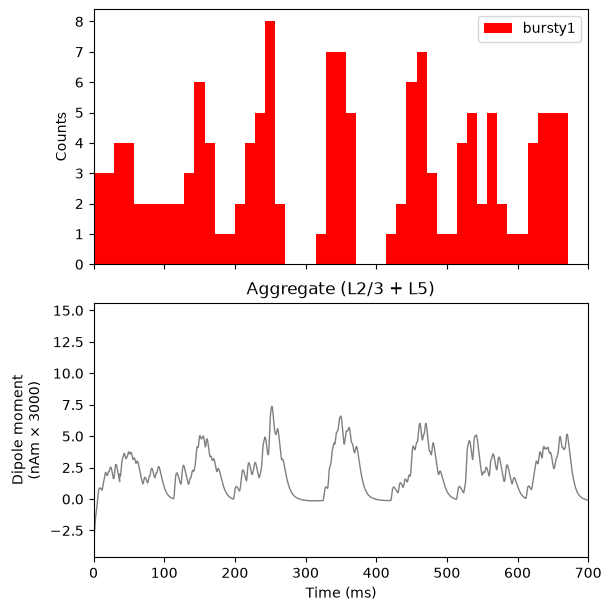

In [8]:
# -----------------------------------------------------------------------
# Run the first simulation and visualize the external input and dipole
# -----------------------------------------------------------------------
dpl = run_simulation(net)

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(6, 6), constrained_layout=True)

# Top panel: external drive spike-time histogram (the single 'bursty1' drive)
net.cell_response.plot_spikes_hist(ax=axes[0], spike_types=['bursty1'], show=False)

# Bottom panel: aggregate dipole waveform
plot_dipole(dpl, ax=axes[1], layer='agg', show=False)

plt.show()

Next, let's show the spectrogram.

The bottom panel shows the corresponding time-frequency spectrogram for this waveform, which exhibits a high-power continuous 10 Hz signal.

Importantly, in this example, the strength of the proximal input spikes were titrated to be subthreshold. In other words, our simulated cortical cells do **not** spike in this instance. This is because we assume that macroscale oscillations are generated primarily by subthreshold current flow across large populations of synchronous pyramidal neurons (see **Section 1. Background** above for details). We will illustrate the relationship between spiking and the signal later, in Section 6.3 (see also our ERP tutorial).

This exploration with a proximal drive is only useful in understanding how subthreshold rhythmic inputs impact the current dipole produced by the circuit. However, several features of the waveform and spectrogram of the signal do *not* match the recorded data shown in Figure 1 and Figure 2. Next, we explore the impact of rhythmic distal inputs only (Section 5), and then a combination of the two (Section 6).

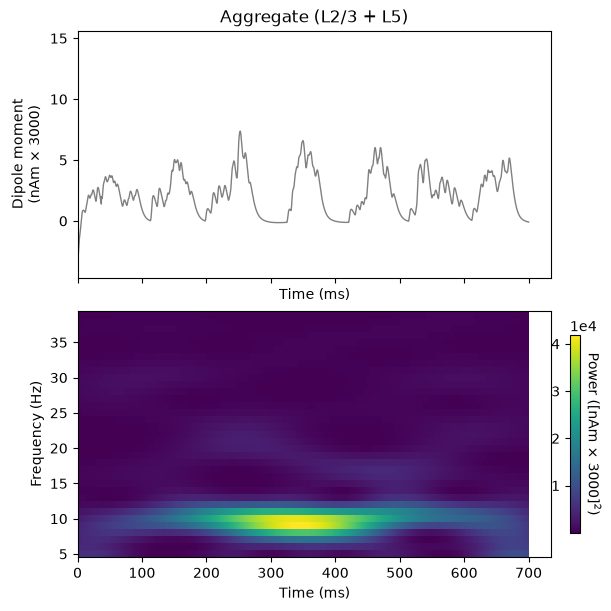

In [9]:
# -----------------------------------------------------------------------
# Reproduce the GUI's `Dipole-Spectrogram (2x1)` visualization template:
# the raw dipole waveform on top, and a Morlet time-frequency
# representation below.
# -----------------------------------------------------------------------
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(6, 6), constrained_layout=True)

dpl.plot(tmin=tmin, ax=axes[0], layer='agg', show=False)
axes[0].set_title('Aggregate (L2/3 + L5)')

dpl.plot_tfr_morlet(
    freqs,
    n_cycles=freqs / 2.0,
    tmin=tmin,
    layer='agg',
    ax=axes[1],
    show=False,
    colormap='viridis'
)

plt.show()

## Packaging the GUI's figures as reusable functions

Rather than repeat all of the visualization code for each simulation, let's package each GUI figure into a function. Each function below is the API equivalent of one GUI visualization template.

In [10]:
LAYER_LABELS = [('L2', 'Layer 2/3'), ('L5', 'Layer 5'), ('agg', 'Aggregate')]

def _drive_names(net):
    """Names of the spiking drives of a network, if it has any.

    Some networks below are driven only by a tonic applied current, and
    therefore have no spiking drive to make a histogram of.
    """
    return list(net.external_drives.keys())


def _distal_drive_names(net, drive_names):
    """Names of the given drives whose target location is 'distal'.

    Distal drives push current up the dendrites rather than down, so we
    invert their histogram bars to visually distinguish them from
    proximal/somatic drives.
    """
    return [name for name in drive_names
            if net.external_drives[name]['location'] == 'distal']


def plot_drive_and_dipole(net, dpl, sim_name, tmin=tmin, tmax=None):
    """Drive histogram + dipole: the GUI's `Simulation` tab output."""
    drive_names = _drive_names(net)
    if len(drive_names) == 0:
        fig, ax = plt.subplots(1, 1, figsize=(6, 3.5), constrained_layout=True)
        axes = [ax]
    else:
        fig, axes = plt.subplots(2, 1, sharex=True, figsize=(6, 6),
                                 constrained_layout=True)
        net.cell_response.plot_spikes_hist(
            ax=axes[0],
            spike_types=drive_names,
            invert_spike_types=_distal_drive_names(net, drive_names),
            color=drive_colors,
            show=False)
    dpl.plot(tmin=tmin, tmax=tmax, layer='agg', ax=axes[-1], show=False)
    fig.suptitle(sim_name)
    plt.show()


def plot_dipole_and_spectrogram(dpl, sim_name, tmin=tmin, tmax=None,
                                freqs=freqs):
    """The GUI's `Dipole-Spectrogram (2x1)` visualization template.

    `freqs` is the frequency range of the spectrogram, equivalent to
    the GUI's `Min/Max Spectral Frequency (Hz)` settings.
    """
    fig, axes = plt.subplots(2, 1, sharex=True, figsize=(6, 6),
                             constrained_layout=True)
    dpl.plot(tmin=tmin, tmax=tmax, layer='agg', ax=axes[0], show=False)
    axes[0].set_title('Aggregate (L2/3 + L5)')
    dpl.plot_tfr_morlet(freqs, n_cycles=freqs / 2.0, tmin=tmin, tmax=tmax,
                        layer='agg', ax=axes[1], show=False, colormap='viridis')
    fig.suptitle(sim_name)
    plt.show()


def plot_drive_and_spikes(net, sim_name):
    """The GUI's `Drive-Spikes (2x1)` visualization template."""
    drive_names = _drive_names(net)
    if len(drive_names) == 0:
        fig, ax = plt.subplots(1, 1, figsize=(6, 3.5), constrained_layout=True)
        axes = [ax]
    else:
        fig, axes = plt.subplots(2, 1, sharex=True, figsize=(6, 6),
                                 constrained_layout=True)
        net.cell_response.plot_spikes_hist(
            ax=axes[0],
            spike_types=drive_names,
            invert_spike_types=_distal_drive_names(net, drive_names),
            color=drive_colors,
            show=False)
    net.cell_response.plot_spikes_raster(trial_idx=trial_idx, ax=axes[-1],
                                         show=False)
    fig.suptitle(sim_name)
    plt.show()


def plot_psd_by_layer(dpl, sim_name, tmin=tmin, tmax=None, fmin=10., fmax=100.):
    """The GUI's `PSD Layers (3x1)` visualization template."""
    fig, axes = plt.subplots(3, 1, figsize=(6, 8), constrained_layout=True)
    for ax, (layer, layer_label) in zip(axes, LAYER_LABELS):
        dpl.plot_psd(fmin=fmin, fmax=fmax, tmin=tmin, tmax=tmax, layer=layer,
                     label='%s (%s)' % (sim_name, layer_label), ax=ax,
                     show=False)
        ax.legend()
    fig.suptitle(sim_name)
    plt.show()

## 5. Simulating Rhythmic Distal Inputs: Alpha Only

### 5.1 Define and view our distal input drive

Similar to 4.1, let's next look at the impact of having **only distal inputs** in our network. Let's load `OnlyRhythmicDist.json`, a network that will simulate the effect of ~10 Hz subthreshold **distal** drive **only**. Let's use `read_network_configuration()` again and inspect the drive.

In [11]:
# Load the first alpha network parameter file.
net_distal_only = read_network_configuration(
    local_alpha_network_files_directory / 'OnlyRhythmicDist.json'
    )

# Print the drive to console
net_distal_only.external_drives

{'bursty2': <External drive 'bursty2'
 drive class: bursty
 target location: distal
 target cell types: ['L2_basket', 'L2_pyramidal', 'L5_basket', 'L5_pyramidal']
 number of drive cells: 10
 cell-specific: False
 dynamic parameters:
 	tstart: 50.0
 	tstart_std: 0.0
 	tstop: 710.0
 	burst_rate: 10.0
 	burst_std: 20.0
 	numspikes: 2
 	spike_isi: 10>}

We now run the simulation and visualize the drive, dipole, and spectrogram
together (c.f. GUI Figures 10 and 11).

Again, the time-frequency spectrogram exhibits a high power continuous 10 Hz signal. Importantly, in this example, the strength of the distal input was also titrated to be subthreshold (i.e., cells do not spike). Again, we will illustrate the relationship between spiking and the signal later, in Section 6.3 (see also our ERP tutorial).

While instructional, this simulation also does not produce waveform and spectral features that match the experimental data in Figure 1 and Figure 2. In the next section (Section 6), we describe how combining **both** the 10 Hz proximal and distal drives can produce an oscillation with many characteristic features of the spontaneous SI signal (Jones et al. 2009).

MPI will run 1 trial(s) sequentially by distributing network neurons over 7 processes.
numprocs=7
Building the NEURON model
[Done]
Trial 1: 0.03 ms...
Trial 1: 10.0 ms...
Trial 1: 20.0 ms...
Trial 1: 30.0 ms...
Trial 1: 40.0 ms...
Trial 1: 50.0 ms...
Trial 1: 60.0 ms...
Trial 1: 70.0 ms...
Trial 1: 80.0 ms...
Trial 1: 90.0 ms...
Trial 1: 100.0 ms...
Trial 1: 110.0 ms...
Trial 1: 120.0 ms...
Trial 1: 130.0 ms...
Trial 1: 140.0 ms...
Trial 1: 150.0 ms...
Trial 1: 160.0 ms...
Trial 1: 170.0 ms...
Trial 1: 180.0 ms...
Trial 1: 190.0 ms...
Trial 1: 200.0 ms...
Trial 1: 210.0 ms...
Trial 1: 220.0 ms...
Trial 1: 230.0 ms...
Trial 1: 240.0 ms...
Trial 1: 250.0 ms...
Trial 1: 260.0 ms...
Trial 1: 270.0 ms...
Trial 1: 280.0 ms...
Trial 1: 290.0 ms...
Trial 1: 300.0 ms...
Trial 1: 310.0 ms...
Trial 1: 320.0 ms...
Trial 1: 330.0 ms...
Trial 1: 340.0 ms...
Trial 1: 350.0 ms...
Trial 1: 360.0 ms...
Trial 1: 370.0 ms...
Trial 1: 380.0 ms...
Trial 1: 390.0 ms...
Trial 1: 400.0 ms...
Trial 1: 410.0 ms.

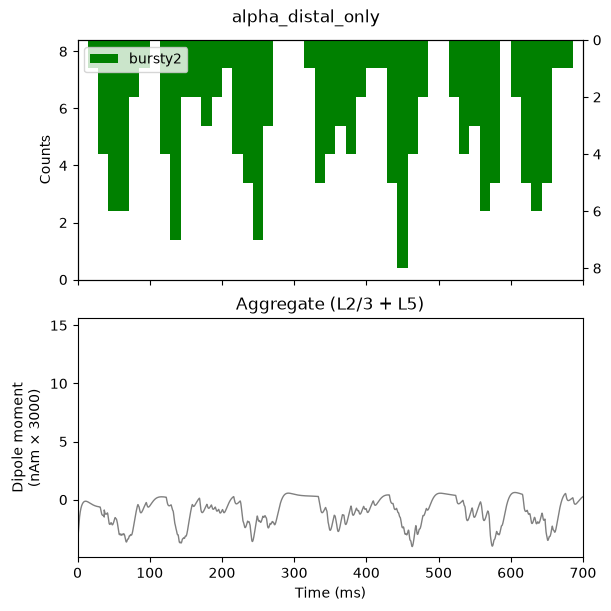

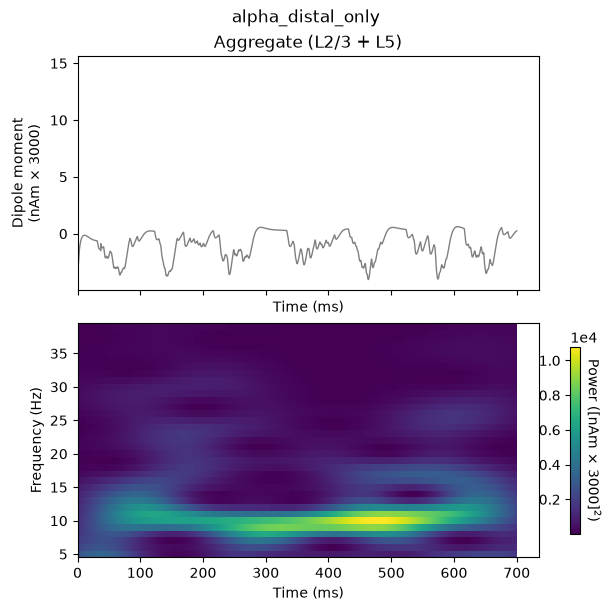

In [12]:
dpl_distal_only = run_simulation(net_distal_only)

plot_drive_and_dipole(net_distal_only, dpl_distal_only, 'alpha_distal_only')
plot_dipole_and_spectrogram(dpl_distal_only, 'alpha_distal_only')

## 6. Simulating Combined Rhythmic Proximal and Distal Inputs: Alpha/Beta Complex

### 6.1 Define and view network drives

This is the API equivalent of loading `AlphaAndBeta.json`. All drive
parameters are the same as in Sections 4 and 5 above (except for the
random `event_seed`s), but now **both** the proximal (`bursty1`) and
distal (`bursty2`) drives are added to the same network, both starting
at `tstart=50` ms so that they arrive nearly synchronously to the network
on each ~10 Hz cycle.

In [13]:
net_alpha_and_beta = read_network_configuration(
    local_alpha_network_files_directory / 'AlphaAndBeta.json'
    )

# Print both the proximal and distal external drives to console
net_alpha_and_beta.external_drives

{'bursty1': <External drive 'bursty1'
 drive class: bursty
 target location: proximal
 target cell types: ['L2_basket', 'L2_pyramidal', 'L5_basket', 'L5_pyramidal']
 number of drive cells: 10
 cell-specific: False
 dynamic parameters:
 	tstart: 50.0
 	tstart_std: 0.0
 	tstop: 710.0
 	burst_rate: 10.0
 	burst_std: 20.0
 	numspikes: 2
 	spike_isi: 10>,
 'bursty2': <External drive 'bursty2'
 drive class: bursty
 target location: distal
 target cell types: ['L2_basket', 'L2_pyramidal', 'L5_basket', 'L5_pyramidal']
 number of drive cells: 10
 cell-specific: False
 dynamic parameters:
 	tstart: 50.0
 	tstart_std: 0.0
 	tstop: 710.0
 	burst_rate: 10.0
 	burst_std: 20.0
 	numspikes: 2
 	spike_isi: 10>}

### 6.2 Run the simulation and visualize the net current dipole

As before, let's run and plot the combined simulation:

MPI will run 1 trial(s) sequentially by distributing network neurons over 7 processes.
numprocs=7
Building the NEURON model
Trial 1: 0.03 ms...
Trial 1: 10.0 ms...
Trial 1: 20.0 ms...
Trial 1: 30.0 ms...
Trial 1: 40.0 ms...
Trial 1: 50.0 ms...
Trial 1: 60.0 ms...
Trial 1: 70.0 ms...
Trial 1: 80.0 ms...
Trial 1: 90.0 ms...
Trial 1: 100.0 ms...
Trial 1: 110.0 ms...
Trial 1: 120.0 ms...
Trial 1: 130.0 ms...
Trial 1: 140.0 ms...
Trial 1: 150.0 ms...
Trial 1: 160.0 ms...
Trial 1: 170.0 ms...
Trial 1: 180.0 ms...
Trial 1: 190.0 ms...
Trial 1: 200.0 ms...
Trial 1: 210.0 ms...
Trial 1: 220.0 ms...
Trial 1: 230.0 ms...
Trial 1: 240.0 ms...
Trial 1: 250.0 ms...
Trial 1: 260.0 ms...
Trial 1: 270.0 ms...
Trial 1: 280.0 ms...
Trial 1: 290.0 ms...
Trial 1: 300.0 ms...
Trial 1: 310.0 ms...
Trial 1: 320.0 ms...
Trial 1: 330.0 ms...
Trial 1: 340.0 ms...
Trial 1: 350.0 ms...
Trial 1: 360.0 ms...
Trial 1: 370.0 ms...
Trial 1: 380.0 ms...
Trial 1: 390.0 ms...
Trial 1: 400.0 ms...
Trial 1: 410.0 ms...
Tria

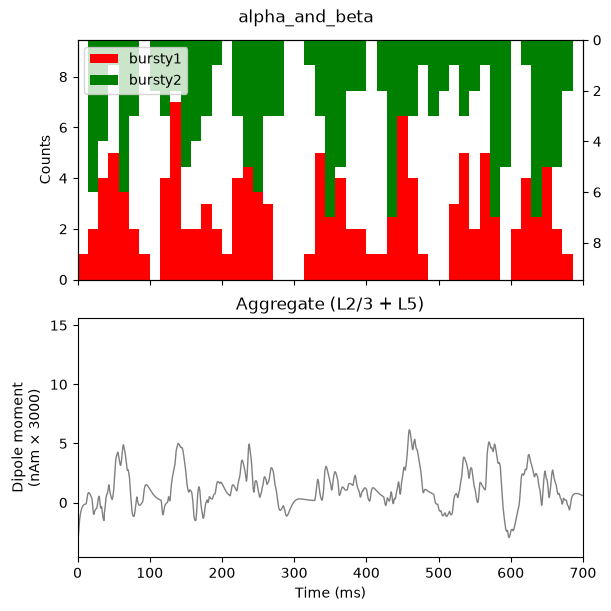

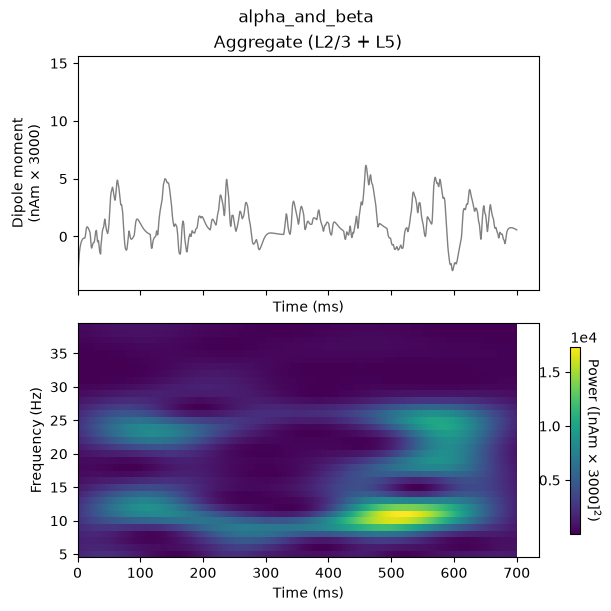

In [14]:
dpl_alpha_and_beta = run_simulation(net_alpha_and_beta)

plot_drive_and_dipole(net_alpha_and_beta, dpl_alpha_and_beta, 'alpha_and_beta')
plot_dipole_and_spectrogram(dpl_alpha_and_beta, 'alpha_and_beta')

As shown in the green and red histogram, with this parameter set, bursts of both proximal and distal input spikes are provided to the network ~10 Hz (i.e., every 100 ms). Due to the stochastic nature of the inputs, there is some variability in the timing and duration of the input bursts: sometimes they arrive at the same time, and sometimes there is a slight offset between them. As a result, intermittent, transient alpha and beta events emerge in the time-frequency spectrogram.

Alpha events are produced when the inputs occur slightly out of phase and current flow is pushed alternately up and down the dendrites for ~50 ms duration each; the current flow of either burst input type does not interfere with the other. Beta events, in contrast, occur when the burst inputs arrive more synchronously; this causes upward current flow to be disrupted by downward current flow for ~50 ms, effectively cutting the oscillation period in half. Therefore, the relative expression of alpha versus beta can be controlled by the relative delay between the inputs and their relative burst strengths.

The current dipole signal of this simulation, shown in the above figure, oscillates above and below 0 nAm, which qualitatively matches the experimental data (see Figure 1 and Figure 2 in Section 1. Background). This is different than the proximal- or distal-only simulations in prior sections, since the current in the pyramidal neurons is pushed both upward and downward in this simulation. Additionally, this simulation reproduces the transient nature of the alpha and beta activity and several other features of the waveform and spectrogram can be quantified to show close agreement between model and experimental results (see Figure 2 above, and (Jones et al. 2009) for further details).

We note that here, we do not directly compare the spontaneous current dipole waveform to recorded data, as is done in the ERP tutorial with a root mean squared error. This is due to the fact that the spontaneous SI signal we are simulating is not time-locked to alpha or beta events on any given trial, and the stochastic nature of the driving inputs causes variability in the timing of the alpha or beta activity, making it difficult to align recorded data and simulated results.

### 6.3 Viewing network spiking activity

Importantly, in all the simulations of this tutorial so far, the strength of the proximal and distal inputs were titrated to be **subthreshold**, meaning that they do not cause our simulated cortical cells to spike. This is based on our assumption that macroscale oscillations are generated primarily by subthreshold current flow across large populations of synchronous pyramidal neurons (see Section 1. Background for references). We can verify the subthreshold nature of the inputs by viewing the spiking activity in the network:

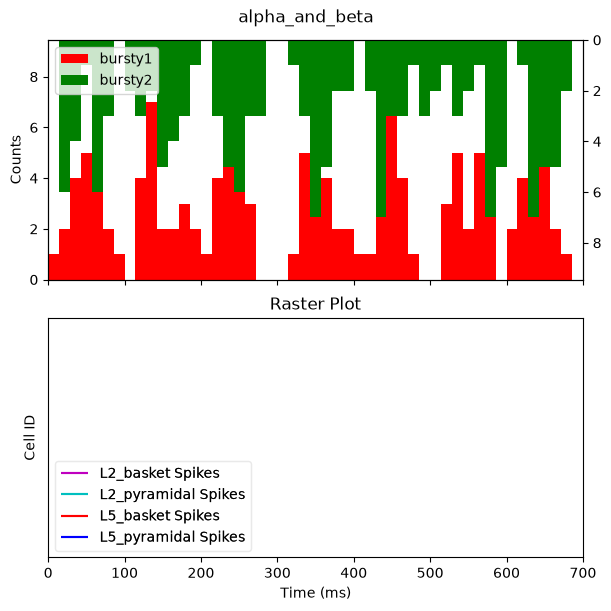

In [15]:
plot_drive_and_spikes(net_alpha_and_beta, 'alpha_and_beta')

As in the GUI, the bottom panel is empty: there is no spiking produced by
any cell in the network. The alpha and beta events above are indeed
produced through purely subthreshold processes.

### 6.4 Simulating and averaging multiple trials with jittered start times

As described in Section 1. Background above, our simulation goal was to study the mechanisms that reproduce features of spontaneous alpha and beta rhythms observed in un-averaged data. These features include the fact that alpha and beta components are transient and intermittent (Figure 1, right panel). Each tutorial section up to this point was based on simulating un-averaged data.

Here, we will show that, depending on the stochastic nature of the proximal and distal rhythmic inputs, alpha and beta activity on different simulation “trial” may be jittered, creating the impression of continuous oscillations. We will describe how to run and average multiple simulation “trials” (700 ms epochs of spontaneous activity), and change the stochasticity by changing the standard deviation of the start times of the drives. This is akin to simulating induced rhythms rather than time-locked evoked rhythms. In the averaged spectrogram across trials, the alpha and beta events will accumulate without cancellation (due to the fact that spectrogram values are purely positive), creating the impression of a continuous oscillation, such as in Figure 1.

For this simulation, we will load `AlphaAndBetaJitter50.json`, and the only difference in the parameters from that of the prior `AlphaAndBeta.json` simulation is that the start time for both drives has been increased from 0 to 50 ms, and that we will be doing multiple trials. Both drives will still input at a 10 Hz rate, but the distal versus proximal inputs are less likely to occur at the same time.

Note that if you do not have MPI installed, you may wish to decrease the number of trials, since this will take some time to run multiple simulations.


In [16]:
net_alpha_and_beta_jitter = read_network_configuration(
    local_alpha_network_files_directory / 'AlphaAndBetaJitter50.json'
    )

# Print both the proximal and distal external drives to console
net_alpha_and_beta_jitter.external_drives

{'bursty1': <External drive 'bursty1'
 drive class: bursty
 target location: proximal
 target cell types: ['L2_basket', 'L2_pyramidal', 'L5_basket', 'L5_pyramidal']
 number of drive cells: 10
 cell-specific: False
 dynamic parameters:
 	tstart: 50.0
 	tstart_std: 50.0
 	tstop: 710.0
 	burst_rate: 10.0
 	burst_std: 20.0
 	numspikes: 2
 	spike_isi: 10>,
 'bursty2': <External drive 'bursty2'
 drive class: bursty
 target location: distal
 target cell types: ['L2_basket', 'L2_pyramidal', 'L5_basket', 'L5_pyramidal']
 number of drive cells: 10
 cell-specific: False
 dynamic parameters:
 	tstart: 50.0
 	tstart_std: 50.0
 	tstop: 710.0
 	burst_rate: 10.0
 	burst_std: 20.0
 	numspikes: 2
 	spike_isi: 10>}

In [17]:
# This is a computationally expensive simulation of 10 trials. If you are 
# not using the MPIBackend or have a slow computer, you may want to 
# reduce the number of trials to 2 or 3 for testing purposes.
jitter_50_n_trials = 10

# For this case, because we want to handle multiple trials, we can't use our simple reusable functions above.
backend = MPIBackend(n_procs=n_procs) if use_mpi else JoblibBackend(n_jobs=1)
with backend:
    dpls_jitter = simulate_dipole(net_alpha_and_beta_jitter, tstop=tstop, n_trials=jitter_50_n_trials)
# Scale every dipole
for idx, dpl in enumerate(dpls_jitter):
    dpls_jitter[idx] = dpl.scale(scaling_factor)

MPI will run 10 trial(s) sequentially by distributing network neurons over 7 processes.
numprocs=7
Building the NEURON model
[Done]
Trial 1: 0.03 ms...
Trial 1: 10.0 ms...
Trial 1: 20.0 ms...
Trial 1: 30.0 ms...
Trial 1: 40.0 ms...
Trial 1: 50.0 ms...
Trial 1: 60.0 ms...
Trial 1: 70.0 ms...
Trial 1: 80.0 ms...
Trial 1: 90.0 ms...
Trial 1: 100.0 ms...
Trial 1: 110.0 ms...
Trial 1: 120.0 ms...
Trial 1: 130.0 ms...
Trial 1: 140.0 ms...
Trial 1: 150.0 ms...
Trial 1: 160.0 ms...
Trial 1: 170.0 ms...
Trial 1: 180.0 ms...
Trial 1: 190.0 ms...
Trial 1: 200.0 ms...
Trial 1: 210.0 ms...
Trial 1: 220.0 ms...
Trial 1: 230.0 ms...
Trial 1: 240.0 ms...
Trial 1: 250.0 ms...
Trial 1: 260.0 ms...
Trial 1: 270.0 ms...
Trial 1: 280.0 ms...
Trial 1: 290.0 ms...
Trial 1: 300.0 ms...
Trial 1: 310.0 ms...
Trial 1: 320.0 ms...
Trial 1: 330.0 ms...
Trial 1: 340.0 ms...
Trial 1: 350.0 ms...
Trial 1: 360.0 ms...
Trial 1: 370.0 ms...
Trial 1: 380.0 ms...
Trial 1: 390.0 ms...
Trial 1: 400.0 ms...
Trial 1: 410.0 ms

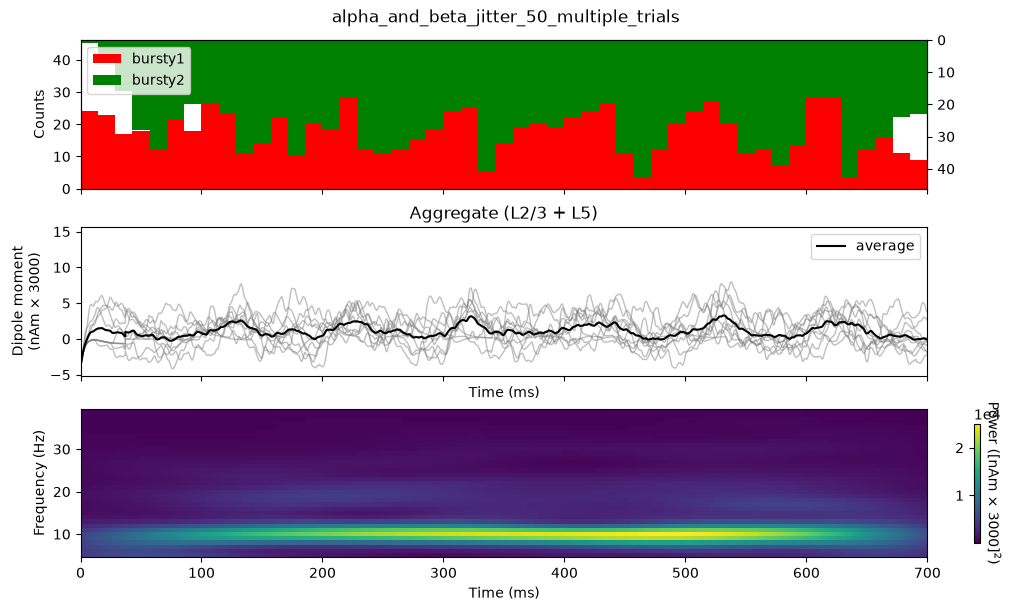

In [18]:
drive_names = _drive_names(net_alpha_and_beta_jitter)
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(10, 6),
                         constrained_layout=True)
net_alpha_and_beta_jitter.cell_response.plot_spikes_hist(
    ax=axes[0],
    spike_types=drive_names,
    invert_spike_types=_distal_drive_names(net_alpha_and_beta_jitter, drive_names),
    color=drive_colors,
    show=False)
plot_dipole(dpls_jitter, tmin=tmin, tmax=tstop, layer='agg', ax=axes[1], average=True, show=False)
axes[1].set_title('Aggregate (L2/3 + L5)')
plot_tfr_morlet(dpls_jitter, freqs, n_cycles=freqs / 2.0, tmin=tmin, tmax=tstop,
                    layer='agg', ax=axes[2], show=False, colormap='viridis')

fig.suptitle("alpha_and_beta_jitter_50_multiple_trials")
plt.show()

Notice that the input histograms for distal (green) and proximal (red)
input, accumulated across the 3 trials, now show less rhythmicity due
to the jitter in the rhythmic input start times across trials
(`tstart_std=50`), in addition to jitter from the inherent burst
variance (`burst_std=20`). This averaged simulation data exhibits
oscillations that appear more continuous than the single-trial example
in Section 6.2 above, and shows relatively more alpha than beta power:
less synchrony between the two drives implies less chance of the signal
going both up and down the dendrites simultaneously.

### 6.5 Exercises for further exploration

Try decreasing or increasing `n_trials` in the simulation above to see
how these changes impact the continuity of alpha/beta power over time.

## 7. Adjusting Parameters

Parameter adjustments are key to developing and testing hypotheses about
the circuit origin of your own low-frequency rhythmic data. Here, we walk
through examples of how adjusting the "Rhythmic Proximal/Distal Input"
drive parameters impacts the alpha and beta rhythms described above.

In the GUI, each of these adjustments is made by editing a value in the
`External drives` tab before re-running the simulation. With the API, we
do the equivalent by re-loading the same `AlphaAndBeta.json` network used
in Section 6, and then modifying only the drive parameters we care about,
in-place, before simulating. Each example below therefore starts from an
identical copy of the Section 6 network, so that the *only* difference
from Section 6 is the parameter we deliberately change.

Timing and synchrony parameters of a drive live in its `dynamics`
dictionary, which we can edit directly, e.g.
`net.external_drives['bursty2']['dynamics']['burst_std'] = 10.0`. The
postsynaptic conductances (`weights_ampa`) are stored differently: they
become part of `net.connectivity`, with one entry per target cell type
and receptor. To change those, we look up the relevant connections with
`pick_connection()` and set their weight. Since we do this more than
once below, let's wrap it in a small helper function.

In [19]:
def set_drive_ampa_weight(net, drive_name, weights_ampa):
    """Change the AMPA weights of an already-loaded drive, in-place.

    Parameters
    ----------
    net : Network
        The network to modify.
    drive_name : str
        Name of the drive to modify, e.g. 'bursty2'.
    weights_ampa : dict
        Mapping of target cell type to new AMPA weight, e.g.
        ``{'L2_pyramidal': 6e-5, 'L5_pyramidal': 6e-5}``.
    """
    for target_type, weight in weights_ampa.items():
        conn_idxs = pick_connection(net, src_gids=drive_name,
                                    target_gids=target_type, receptor='ampa')
        for conn_idx in conn_idxs:
            net.connectivity[conn_idx]['nc_dict']['A_weight'] = weight
        # Also update the drive's own record of its weights, so that
        # printing the drive below reflects the change.
        net.external_drives[drive_name]['weights_ampa'][target_type] = weight



### 7.1 Increasing the strength and synchrony of the distal drive increases beta activity

We saw in Section 6.2 that the relative timing of proximal and distal
inputs determines whether alpha or beta events emerge. Another factor
that increases the prevalence of beta activity is the strengthened
synchrony of the distal drive. Beta activity increases with a stronger,
more synchronous subthreshold distal drive, where the beta frequency is
set by the duration of the driving bursts (~50 ms). The strength is
controlled by the postsynaptic conductance (`weights_ampa`), and the
synchrony is controlled by `burst_std`. Here we:

* Decrease `burst_std` of the distal drive from `20` to `10` ms.
* Increase `weights_ampa` of the distal drive to both `L2_pyramidal` and
  `L5_pyramidal` from `5.4e-5` to `6e-5`.

Both changes push a greater amount of current flow down the pyramidal
neuron dendrites, more synchronously.

In [20]:
# Start from the same network as Section 6 ...
net_incr_beta = read_network_configuration(
    local_alpha_network_files_directory / 'AlphaAndBeta.json'
    )

# ... then modify only the distal drive ('bursty2'), in-place.

# 1. More synchronous distal bursts: burst_std from 20 to 10 ms.
net_incr_beta.external_drives['bursty2']['dynamics']['burst_std'] = 10.0

# 2. Stronger distal input: weights_ampa onto both pyramidal
#    populations from 5.4e-5 to 6e-5.
set_drive_ampa_weight(
    net_incr_beta, 'bursty2',
    {'L2_pyramidal': 6e-5, 'L5_pyramidal': 6e-5})

# Print the modified distal drive to console, to confirm our changes
net_incr_beta.external_drives['bursty2']


<External drive 'bursty2'
drive class: bursty
target location: distal
target cell types: ['L2_basket', 'L2_pyramidal', 'L5_basket', 'L5_pyramidal']
number of drive cells: 10
cell-specific: False
dynamic parameters:
	tstart: 50.0
	tstart_std: 0.0
	tstop: 710.0
	burst_rate: 10.0
	burst_std: 10.0
	numspikes: 2
	spike_isi: 10>

MPI will run 1 trial(s) sequentially by distributing network neurons over 7 processes.
numprocs=7
Building the NEURON model
[Done]
Trial 1: 0.03 ms...
Trial 1: 10.0 ms...
Trial 1: 20.0 ms...
Trial 1: 30.0 ms...
Trial 1: 40.0 ms...
Trial 1: 50.0 ms...
Trial 1: 60.0 ms...
Trial 1: 70.0 ms...
Trial 1: 80.0 ms...
Trial 1: 90.0 ms...
Trial 1: 100.0 ms...
Trial 1: 110.0 ms...
Trial 1: 120.0 ms...
Trial 1: 130.0 ms...
Trial 1: 140.0 ms...
Trial 1: 150.0 ms...
Trial 1: 160.0 ms...
Trial 1: 170.0 ms...
Trial 1: 180.0 ms...
Trial 1: 190.0 ms...
Trial 1: 200.0 ms...
Trial 1: 210.0 ms...
Trial 1: 220.0 ms...
Trial 1: 230.0 ms...
Trial 1: 240.0 ms...
Trial 1: 250.0 ms...
Trial 1: 260.0 ms...
Trial 1: 270.0 ms...
Trial 1: 280.0 ms...
Trial 1: 290.0 ms...
Trial 1: 300.0 ms...
Trial 1: 310.0 ms...
Trial 1: 320.0 ms...
Trial 1: 330.0 ms...
Trial 1: 340.0 ms...
Trial 1: 350.0 ms...
Trial 1: 360.0 ms...
Trial 1: 370.0 ms...
Trial 1: 380.0 ms...
Trial 1: 390.0 ms...
Trial 1: 400.0 ms...
Trial 1: 410.0 ms.

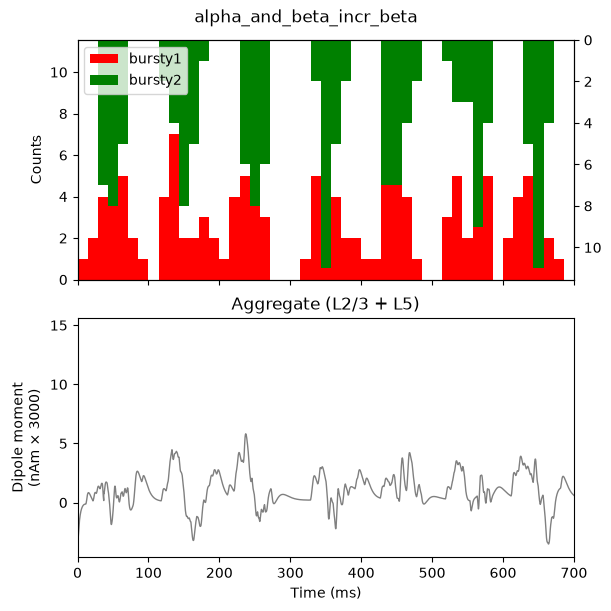

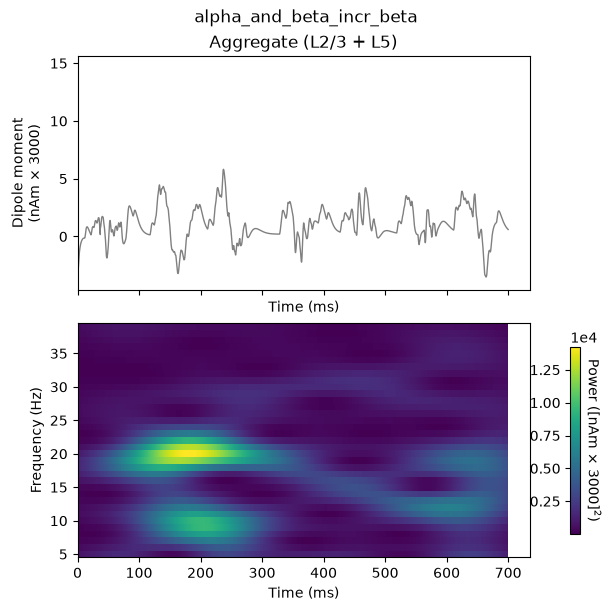

In [21]:
dpl_incr_beta = run_simulation(net_incr_beta)

plot_drive_and_dipole(net_incr_beta, dpl_incr_beta, 'alpha_and_beta_incr_beta')
plot_dipole_and_spectrogram(dpl_incr_beta, 'alpha_and_beta_incr_beta')

The histogram profile of the distal input bursts (green) is narrower,
corresponding to more synchronous input than in the original
`AlphaAndBeta` simulation. The waveform also shows a sharper, downward
(negative) deflecting signal due to the stronger distal input. These
sharper deflections lead to increased ~20 Hz beta activity relative to
10 Hz alpha activity in the spectrogram, compared with Section 6.2. The
20 Hz frequency is set by the duration of the downward current flow,
here approximately 50 ms.

#### 7.1.1 Exercise for further exploration

Try changing the frequency of the rhythmic distal drive from 10 Hz to 20
Hz by setting `burst_rate`. Try other frequencies for the proximal and
distal rhythmic drives. How do the rhythms change? See how further
changes in `burst_std` affect the rhythms expressed.

### 7.2 Increasing the delay between proximal and distal inputs creates continuous alpha oscillations without beta activity

In addition to drive strength and synchrony, the relative *timing*
between proximal and distal inputs is an important factor in determining
the relative alpha and beta expression in the model. Here we demonstrate
that out-of-phase 10 Hz burst inputs can produce continuous alpha
activity *without* any beta events, by increasing the proximal drive's
`tstart` from `50` to `100` ms. Since the distal input still starts at
`tstart=50` ms, the two drives will now arrive to the network, on
average, a half-cycle out of phase (i.e., in antiphase, every 50 ms).

In [27]:
# Start from the same network as Section 6 ...
net_alpha_only = read_network_configuration(
    local_alpha_network_files_directory / 'AlphaAndBeta.json'
    )

# ... then delay the proximal drive ('bursty1') only: tstart from 50 to
# 100 ms, so that it arrives a half-cycle after the distal drive 
# ('bursty2'), which still starts at tstart=50 ms.
net_alpha_only.external_drives['bursty1']['dynamics']['tstart'] = 100.0

# Print the drives to console, to confirm our change
net_alpha_only.external_drives


{'bursty1': <External drive 'bursty1'
 drive class: bursty
 target location: proximal
 target cell types: ['L2_basket', 'L2_pyramidal', 'L5_basket', 'L5_pyramidal']
 number of drive cells: 10
 cell-specific: False
 dynamic parameters:
 	tstart: 100.0
 	tstart_std: 0.0
 	tstop: 710.0
 	burst_rate: 10.0
 	burst_std: 20.0
 	numspikes: 2
 	spike_isi: 10>,
 'bursty2': <External drive 'bursty2'
 drive class: bursty
 target location: distal
 target cell types: ['L2_basket', 'L2_pyramidal', 'L5_basket', 'L5_pyramidal']
 number of drive cells: 10
 cell-specific: False
 dynamic parameters:
 	tstart: 50.0
 	tstart_std: 0.0
 	tstop: 710.0
 	burst_rate: 10.0
 	burst_std: 20.0
 	numspikes: 2
 	spike_isi: 10>}

MPI will run 1 trial(s) sequentially by distributing network neurons over 7 processes.
numprocs=7
Building the NEURON model
[Done]
Trial 1: 0.03 ms...
Trial 1: 10.0 ms...
Trial 1: 20.0 ms...
Trial 1: 30.0 ms...
Trial 1: 40.0 ms...
Trial 1: 50.0 ms...
Trial 1: 60.0 ms...
Trial 1: 70.0 ms...
Trial 1: 80.0 ms...
Trial 1: 90.0 ms...
Trial 1: 100.0 ms...
Trial 1: 110.0 ms...
Trial 1: 120.0 ms...
Trial 1: 130.0 ms...
Trial 1: 140.0 ms...
Trial 1: 150.0 ms...
Trial 1: 160.0 ms...
Trial 1: 170.0 ms...
Trial 1: 180.0 ms...
Trial 1: 190.0 ms...
Trial 1: 200.0 ms...
Trial 1: 210.0 ms...
Trial 1: 220.0 ms...
Trial 1: 230.0 ms...
Trial 1: 240.0 ms...
Trial 1: 250.0 ms...
Trial 1: 260.0 ms...
Trial 1: 270.0 ms...
Trial 1: 280.0 ms...
Trial 1: 290.0 ms...
Trial 1: 300.0 ms...
Trial 1: 310.0 ms...
Trial 1: 320.0 ms...
Trial 1: 330.0 ms...
Trial 1: 340.0 ms...
Trial 1: 350.0 ms...
Trial 1: 360.0 ms...
Trial 1: 370.0 ms...
Trial 1: 380.0 ms...
Trial 1: 390.0 ms...
Trial 1: 400.0 ms...
Trial 1: 410.0 ms.

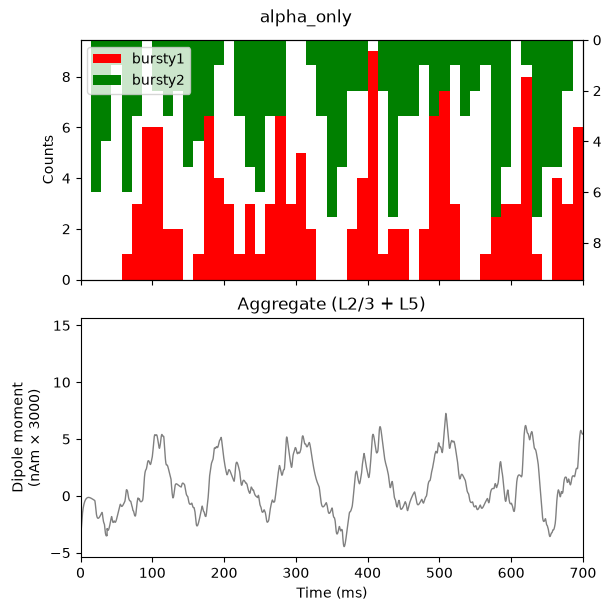

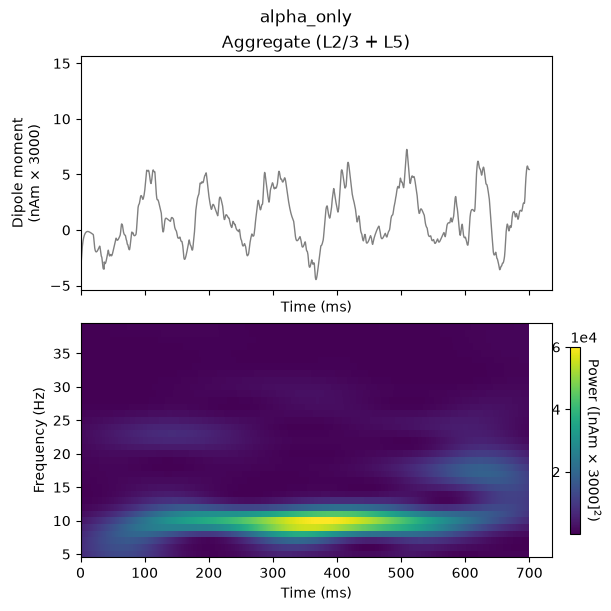

In [23]:
dpl_alpha_only = run_simulation(net_alpha_only)

plot_drive_and_dipole(net_alpha_only, dpl_alpha_only, 'alpha_only')
plot_dipole_and_spectrogram(dpl_alpha_only, 'alpha_only')


The histogram profile of the proximal (red) and distal (green) input
bursts are generally half a cycle out-of-phase (antiphase). This
alternation of proximal, followed by distal, drive induces alternating
subthreshold current flow up and down the pyramidal neuron dendrites,
creating a continuous alpha oscillation in the current dipole waveform
that oscillates around 0 nAm. The corresponding spectrogram shows
continuous, nearly-pure alpha activity, in contrast to the intermittent
alpha and beta seen in Section 6.2. This type of strong alpha activity
is similar to what might be observed over occipital cortex during
eyes-closed conditions.

#### 7.2.1 Exercise for further exploration

Try changing the delay between the proximal and distal drives by varying
amounts (i.e., other values of `tstart`). What happens to the rhythm
expressed? Can you create a simulation where other frequencies are
expressed? How is it created? Are the cells spiking or subthreshold?

### 7.3 Increasing the strength of the distal drive further creates high-frequency responses due to induced spiking activity

In all simulations so far, the strength of the rhythmic proximal and
distal inputs was chosen so that the simulated cells remained
subthreshold (no spiking). We now demonstrate what happens when the
distal drive strength is increased far enough to induce spikes. Instead
of subthreshold alpha/beta events, the dipole signal becomes dominated by
higher-frequency events created by spiking activity. This type of
activity is not typically observed in MEG or EEG data, supporting the
notion that alpha/beta rhythms are created through subthreshold
processes.

We increase `weights_ampa` of the distal drive to both `L2_pyramidal` and
`L5_pyramidal` from `5.4e-5` to `4e-4` (note the change in the exponent!),
and widen the spectrogram frequency range from 5-40 Hz to 5-120 Hz
(c.f. GUI's `Max Spectral Frequency (Hz)` change from `40` to `120`).

In [ ]:
# Start from the same network as Section 6 ...
net_high_freq = read_network_configuration(
    local_alpha_network_files_directory / 'AlphaAndBeta.json'
    )

# ... then greatly increase the strength of the distal drive
# ('bursty2') only: weights_ampa onto both pyramidal populations from
# 5.4e-5 to 4e-4 (note the change in the exponent!).
set_drive_ampa_weight(
    net_high_freq, 'bursty2',
    {'L2_pyramidal': 4e-4, 'L5_pyramidal': 4e-4})

<External drive 'bursty2'
drive class: bursty
target location: distal
target cell types: ['L2_basket', 'L2_pyramidal', 'L5_basket', 'L5_pyramidal']
number of drive cells: 10
cell-specific: False
dynamic parameters:
	tstart: 50.0
	tstart_std: 0.0
	tstop: 710.0
	burst_rate: 10.0
	burst_std: 20.0
	numspikes: 2
	spike_isi: 10>

MPI will run 1 trial(s) sequentially by distributing network neurons over 7 processes.
numprocs=7
Building the NEURON model
[Done]
Trial 1: 0.03 ms...
Trial 1: 10.0 ms...
Trial 1: 20.0 ms...
Trial 1: 30.0 ms...
Trial 1: 40.0 ms...
Trial 1: 50.0 ms...
Trial 1: 60.0 ms...
Trial 1: 70.0 ms...
Trial 1: 80.0 ms...
Trial 1: 90.0 ms...
Trial 1: 100.0 ms...
Trial 1: 110.0 ms...
Trial 1: 120.0 ms...
Trial 1: 130.0 ms...
Trial 1: 140.0 ms...
Trial 1: 150.0 ms...
Trial 1: 160.0 ms...
Trial 1: 170.0 ms...
Trial 1: 180.0 ms...
Trial 1: 190.0 ms...
Trial 1: 200.0 ms...
Trial 1: 210.0 ms...
Trial 1: 220.0 ms...
Trial 1: 230.0 ms...
Trial 1: 240.0 ms...
Trial 1: 250.0 ms...
Trial 1: 260.0 ms...
Trial 1: 270.0 ms...
Trial 1: 280.0 ms...
Trial 1: 290.0 ms...
Trial 1: 300.0 ms...
Trial 1: 310.0 ms...
Trial 1: 320.0 ms...
Trial 1: 330.0 ms...
Trial 1: 340.0 ms...
Trial 1: 350.0 ms...
Trial 1: 360.0 ms...
Trial 1: 370.0 ms...
Trial 1: 380.0 ms...
Trial 1: 390.0 ms...
Trial 1: 400.0 ms...
Trial 1: 410.0 ms.

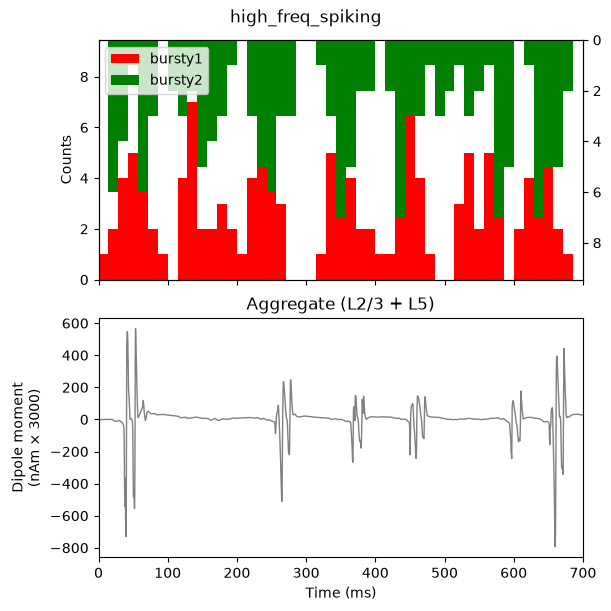

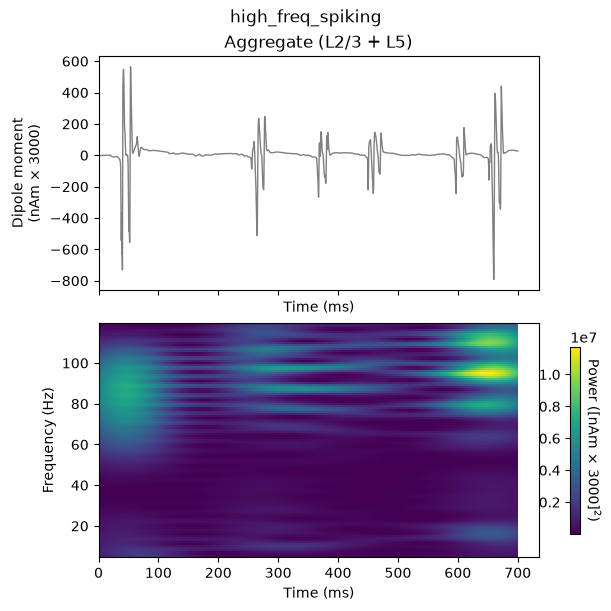

In [25]:
dpl_high_freq = run_simulation(net_high_freq)

# Widen the spectrogram range from 5-40 Hz to 5-120 Hz, equivalent to
# the GUI's `Max Spectral Frequency (Hz)` change from 40 to 120.
freqs_wide = np.arange(5., 120., 1.)

plot_drive_and_dipole(net_high_freq, dpl_high_freq, 'high_freq_spiking')
plot_dipole_and_spectrogram(dpl_high_freq, 'high_freq_spiking',
                            freqs=freqs_wide)


Because we greatly increased the postsynaptic conductance of the distal
driving spikes, the distal input now induces spiking activity in the
pyramidal neurons on several cycles of the drive, resulting in a sharp,
rapidly oscillating dipole waveform, and broadband ~60-120 Hz activity in
the spectrogram. Next, we verify that the neurons are indeed spiking by
overlaying the spiking rastergram on top of each layer's contribution to
the dipole signal, using `plot_spikes_raster(..., overlay_dipoles=True)`
(c.f. GUI's `Dipole Layers-Spikes (1x1)` layout).

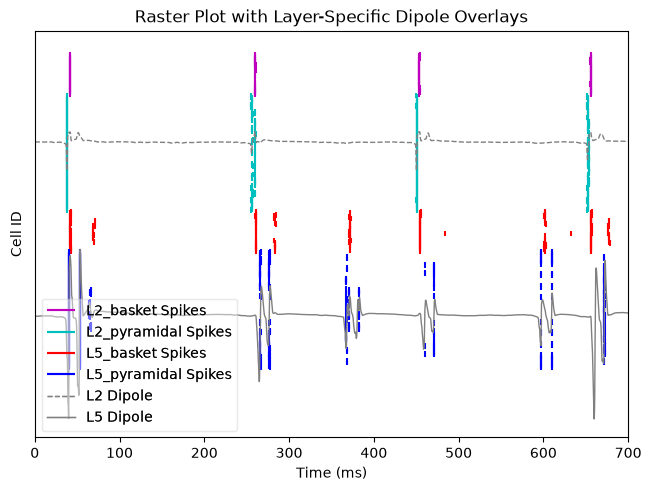

In [28]:
net_high_freq.cell_response.plot_spikes_raster(
    dpl=dpl_high_freq, overlay_dipoles=True, show=False)
plt.show()


The grey lines correspond to each layer's contribution to the dipole
signal seen above, while the other colors represent spikes of each cell
population. Highly synchronous neuronal spiking in each population
coincides with the high-frequency events seen in the dipole signal. These
high-frequency waveforms are induced by the pyramidal neurons spiking,
which create rapid, back-propagating action potentials and repolarization
of the dendrites.

#### 7.3.1 Exercise for further exploration

View the contribution of Layer 2/3 and Layer 5 separately to the net
current dipole waveform (`layer='L2'` and `layer='L5'` in `plot_dipole()`
/ `plot_tfr_morlet()`) and compare with the spiking activity in each
population. How does each layer contribute? Try changing the *proximal*
input parameters instead of the distal input parameters -- can you elicit
high-frequency spiking using proximal input changes only? Finally, try
adjusting one of the parameters regulating the local network connections
(e.g. via `net.connectivity`, not covered in this tutorial). What
happens?

## References

Hughes, Stuart W., and Vincenzo Crunelli. 2005. “Thalamic Mechanisms of EEG Alpha Rhythms and Their Pathological Implications.” The Neuroscientist 11 (4): 357–72. [https://doi.org/10.1177/1073858405277450](https://doi.org/10.1177/1073858405277450).

Jones, Edward G. 2001. “The Thalamic Matrix and Thalamocortical Synchrony.” Trends in Neurosciences 24 (10): 595–601. [https://doi.org/10.1016/S0166-2236(00)01922-6](https://doi.org/10.1016/S0166-2236(00)01922-6).

Jones, Stephanie R. 2016. “When Brain Rhythms Aren’t ‘Rhythmic’: Implication for Their Mechanisms and Meaning.” Current Opinion in Neurobiology, Systems neuroscience, 40 (October): 72–80. [https://doi.org/10.1016/j.conb.2016.06.010](https://doi.org/10.1016/j.conb.2016.06.010).

Jones, Stephanie R., Dominique L. Pritchett, Michael A. Sikora, Steven M. Stufflebeam, Matti Hämäläinen, and Christopher I. Moore. 2009. “Quantitative Analysis and Biophysically Realistic Neural Modeling of the MEG Mu Rhythm: Rhythmogenesis and Modulation of Sensory-Evoked Responses.” Journal of Neurophysiology 102 (6): 3554–72. [https://doi.org/10.1152/jn.00535.2009](https://doi.org/10.1152/jn.00535.2009).

Sherman, Maxwell A., Shane Lee, Robert Law, Saskia Haegens, Catherine A. Thorn, Matti S. Hämäläinen, Christopher I. Moore, and Stephanie R. Jones. 2016. “Neural Mechanisms of Transient Neocortical Beta Rhythms: Converging Evidence from Humans, Computational Modeling, Monkeys, and Mice.” Proceedings of the National Academy of Sciences 113 (33): E4885–94. [https://doi.org/10.1073/pnas.1604135113](https://doi.org/10.1073/pnas.1604135113).

Zhu, Zhao, Johanna M. Zumer, Marianne E. Lowenthal, Jeff Padberg, Gregg H. Recanzone, Leah A. Krubitzer, Srikantan S. Nagarajan, and Elizabeth A. Disbrow. 2009. “The Relationship Between Magnetic and Electrophysiological Responses to Complex Tactile Stimuli.” BMC Neuroscience 10 (1): 4. [https://doi.org/10.1186/1471-2202-10-4](https://doi.org/10.1186/1471-2202-10-4).

Ziegler, David A., Dominique L. Pritchett, Paymon Hosseini-Varnamkhasti, Suzanne Corkin, Matti Hämäläinen, Christopher I. Moore, and Stephanie R. Jones. 2010. “Transformations in Oscillatory Activity and Evoked Responses in Primary Somatosensory Cortex in Middle Age: A Combined Computational Neural Modeling and MEG Study.” NeuroImage 52 (3): 897–912. [https://doi.org/10.1016/j.neuroimage.2010.02.004](https://doi.org/10.1016/j.neuroimage.2010.02.004).